# A tax-return red flag for stocks — that blue chips shrug off 🧮
### When a company's book profit towers over the profit its tax bill implies, is that a warning? On 39 giants, it warns of *nothing*.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Persistence%3F: Not detected](https://img.shields.io/badge/Persistence%3F-Not_detected-8b949e?style=flat-square)

Every company keeps two sets of books — legally. One follows accounting rules (the **book income** you see on the income statement); the other follows the tax code (the **taxable income** the IRS actually taxes). They almost never match. When book income sits *far above* the taxable income its tax bill implies — a big **book-tax difference** — a famous accounting paper (Hanlon 2005) says be careful: those earnings are being propped up by things that haven't hit the tax return, so they're **less likely to last**, and the stock should do worse.

Great story. So we ranked 39 big US companies on exactly that gap and checked both halves of the claim — the returns *and* the fragile-earnings part. Neither one shows up.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the persistence regression? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 42 large US filers (39 with usable history), annual 10-K figures 2007→2026; a **thin panel skewed to the wrong tail** — these blue chips are where book-tax gaps are *smallest*. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from book_tax_diff import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 39, 'n_events': 569, 'end_lo': '2007-12-31', 'end_hi': '2025-12-31', 'fp_prices': 'd579ef33a57f', 'share_pos_btd': 71, 'btd_med': 2.1, 'n_months': 196, 'avg_n': 29.9, 'ls_span_lo': '2010-03-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 20.1, 'ls_ann': 2.42, 'ls_t_iid': 0.75, 'ls_t_nw': 0.74, 'ls_sharpe': 0.19, 'ls_hit': 49, 'ls_long_bps': 151.9, 'ls_short_bps': 131.8, 'ls_turn': 0.05, 'ls_cum': 1.29, 'change_mean_bps': 37.9, 'change_t_nw': 1.79, 'change_sharpe': 0.47, 'xsec_early': 6, 'xsec_late': 37, 'drift': {63: (569, 2.8, 3.0, -0.2, -0.15, 47, 0.5674), 126: (551, 4.95, 7.42, -2.47, -1.43, 49, 0.9369), 252: (541, 15.73, 17.35, -1.62, -0.55, 49, 0.7285)}, 'mono252': (17.35, 16.22, 15.73), 'era_early_n': 94, 'era_early_bps': 29.2, 'era_early_t': 0.94, 'era_late_n': 102, 'era_late_bps': 11.8, 'era_late_t': 0.27, 'pers_n': 530, 'b_all': 0.75, 'b_low': 0.75, 'b_high': 0.752, 'pers_diff': 0.002, 'pers_t': 0.03, 'pers_r2': 0.57, 'net': {(10, 50): (15.0, 1.8, 0.55, 0.14), (20, 100): (9.8, 1.18, 0.36, 0.09)}, 'syn_null_mean': 0.31, 'syn_null_sd': 0.67, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 62.8, 'syn_planted_t': 2.55}


real cache present: True | events: 569 | names: 39


## The answer first

| Question | Answer |
|---|---|
| Does a big book-tax gap predict **lower returns**? | **Not in any way we can certify.** A long-short that owns the low-gap names and shorts the high-gap ones is *right-signed* (+2.4%/yr on paper) but statistically nothing (robust *t* = **+0.74**, the bar is 2) — and a second way of measuring it actually leans the **opposite** way. |
| Does it mark **fragile (less-persistent) earnings**? | **No.** That's Hanlon's actual headline, and here it's flat: high-gap firms' earnings persist **0.752** vs low-gap firms' **0.750** — the same number. |
| Why the nothing? | We're looking in the wrong place *on purpose*: big, clean, heavily-audited blue chips are where these gaps are smallest and best-explained. The red flag lives in the messy tail — small, distressed, shelter-heavy names — none of which are in a large-cap survivor basket. |
| Can you trade it? | **No.** The return edge doesn't clear the bar even before costs. |

> A red flag that, waved at blue chips, flags nothing — neither the stock nor the earnings behind it.

## 1 · The claim

> *"Book income far above the income the tax bill implies means the earnings are inflated by soft, reversing items. Short the big-gap 'aggressive' names, own the low-gap 'clean' ones."*

It's a specific, tax-flavoured case of a respectable academic idea — the market misprices the *accrual* pieces of earnings (Sloan 1996). The book-tax gap is an unusually clean read on one accrual: the stuff accounting counts as profit that the tax code doesn't (yet). Hanlon (2005) showed such firms have **less persistent earnings**. The question is whether that's *tradeable* — and whether it even holds among household-name companies.

## 2 · So what?

If one number from the tax footnote flagged which stocks would lag, it would be a gift — it's in every 10-K, no estimates feed, no alt-data. That's exactly why it deserves suspicion: it's *too* readable. And there's a second reason to doubt it here — **71%** of these firm-years already show book income *above* the tax-implied figure (median gap ≈2% of assets). A 'positive book-tax difference' is the normal state of a profitable company, not an exotic warning sign. So 'large' has to be doing a lot of work — and on blue chips, it isn't.

## 3 · How would we even know?

- **The signal.** For each of 39 big US companies, the book-tax gap = (pretax book income − the taxable income its tax bill implies) ÷ assets, from the annual 10-K, known only on the **filing date** (no peeking at a number before it's public). We gross up the tax bill by the **statutory rate** — 35% before 2018, 21% after the tax-cut law.
- **The return test.** Each month, rank the names on the gap, buy the low-gap third, short the high-gap third, hold one month. Does the spread make money — and can we tell it apart from noise?
- **The earnings test.** Do the high-gap names' profits actually persist less next year? (Hanlon's real claim.)
- **The mirage check.** If the return spread can't beat a coin-flip relabelling of the names, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**Start with the mechanism, because it's the cleanest test.** Hanlon says high-gap earnings are *fragile* — this year's profit is a worse guide to next year's. So we measure how well each group's ROA carries over to the following year, and compare the biggest-gap third to the smallest-gap third.

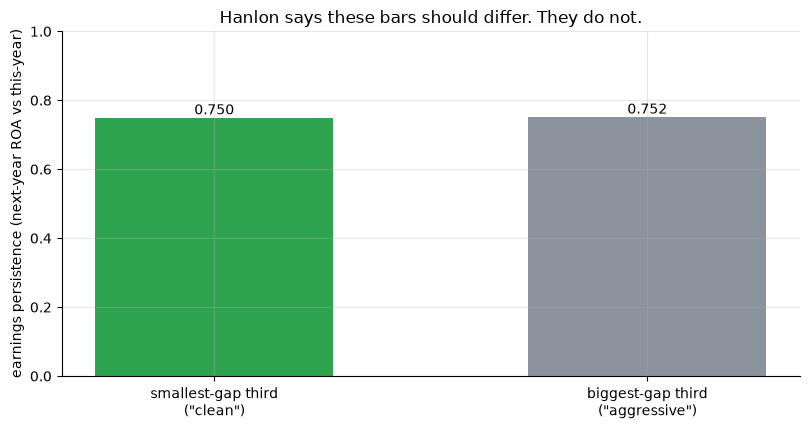

earnings persistence: clean 0.750 vs aggressive 0.752 -> gap +0.002 (should be clearly negative if the claim held)


In [2]:
if HAVE_REAL:
    q = st.earnings_persistence(EV)
    b_low, b_high = q['b_low'], q['b_high']
else:
    b_low, b_high = R['b_low'], R['b_high']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['smallest-gap third\n("clean")','biggest-gap third\n("aggressive")'],
       [b_low, b_high], color=[GREEN, GREY], width=.55)
for i,v in enumerate([b_low, b_high]): ax.annotate(f'{v:.3f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('earnings persistence (next-year ROA vs this-year)')
ax.set_ylim(0, 1.0)
ax.set_title('Hanlon says these bars should differ. They do not.')
plt.tight_layout(); plt.show()
print(f'earnings persistence: clean {b_low:.3f} vs aggressive {b_high:.3f} '
      f'-> gap {b_high-b_low:+.3f} (should be clearly negative if the claim held)')

The two bars are **the same height** — persistence 0.750 for the clean third, 0.752 for the aggressive third, a gap of **+0.002** (statistically zero). On these names, a big book-tax difference does **not** mark fragile earnings. The engine the whole claim runs on isn't turning over.

**So does the stock at least move?** Same ranking, but now we measure the forward *return* of a buy-the-low-gap, short-the-high-gap portfolio, rebalanced monthly.

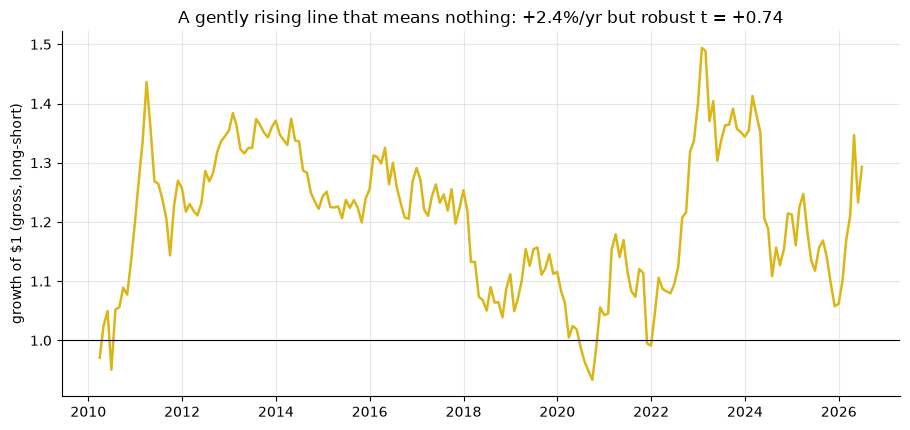

long-short: +2.4%/yr gross, but Newey-West t = +0.74 (the bar is 2)


In [3]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='btd_neg', n_buckets=3, min_names=6, staleness_days=430)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=AMBER, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'A gently rising line that means nothing: +{ann:.1f}%/yr but robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: +{ann:.1f}%/yr gross, but Newey-West t = {tnw:+.2f} (the bar is 2)')

It *drifts up* — **+2.4%/yr** gross, growing \$1 to \$1.29 over 196 months, and it's right-signed (clean beats aggressive, as Hanlon would want). But that's the trap. Once you account for how noisy those monthly returns are, the robust *t* is **+0.74** — nowhere near the **2** we require. A line that slopes up and a *reliable* edge are different things.

**And here's the tell that kills it:** measure the same names a second way — the raw drift after each filing, sorted by gap size — and the ranking *flips*. The biggest-gap names, the ones you're supposed to short, actually drift *up* a touch more.

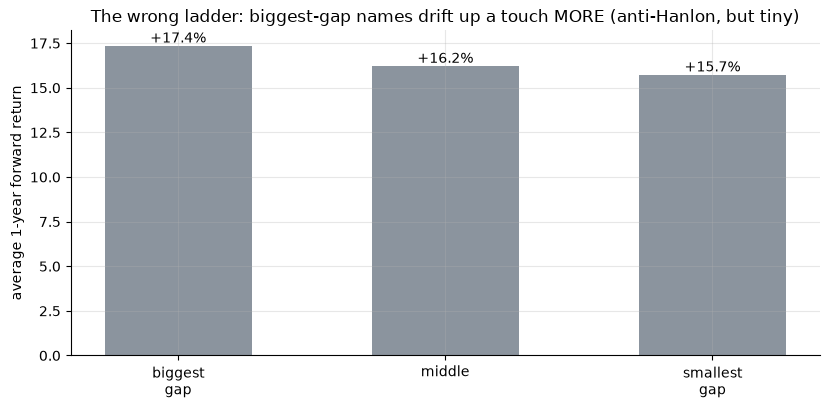

1-year forward return by gap size (biggest->smallest): ['+17.4%', '+16.2%', '+15.7%']


In [4]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=252)
    mono = st.bucket_means(fr, 3)*100     # buckets of btd_neg low->high == BTD high->low
else:
    mono = np.array(R['mono252'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['biggest\ngap','middle','smallest\ngap'], mono,
       color=[GREY, GREY, GREY], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 1-year forward return')
ax.set_title('The wrong ladder: biggest-gap names drift up a touch MORE (anti-Hanlon, but tiny)')
plt.tight_layout(); plt.show()
print('1-year forward return by gap size (biggest->smallest):', [f'{v:+.1f}%' for v in mono])

Sorted by gap size, the forward returns run **+17.4% / +16.2% / +15.7%** from biggest to smallest gap — a faint slope in the **opposite** direction to the claim, and far too small to be real. One way of measuring says clean-beats-aggressive; the other says the reverse; both are indistinguishable from zero. That's what *no signal* looks like: the sign isn't even stable.

## 5 · The verdict

- **Fragile earnings? — Not detected.** The mechanism Hanlon documented is flat here: persistence 0.750 (clean) vs 0.752 (aggressive). No difference.
- **Signal (returns) — Weak.** The long-short is right-signed and ~+2.4%/yr on paper, but never clears the bar (robust *t* = +0.74), the second measurement leans the other way, and neither era certifies. A whiff of the story, nothing this tape can stand behind.
- **Tradability — Mirage.** You can't get paid for an edge you can't distinguish from luck. It fails before costs are even charged.

> The honest one-liner: *the book-tax red flag may well work in the messy corners of the market — but on blue chips it flags neither the earnings nor the stock.*

## 6 · Going further 🚪

- **Where the effect probably still lives.** Not in mega-caps but in the **broad cross-section** — small, distressed, tax-shelter-heavy names where book and tax income genuinely part ways and few analysts are watching. A survivor basket of giants is the *hardest* place for this signal, by construction. The null here refutes the *blue-chip* version, not Hanlon's.
- **The coverage caveat is real.** The cross-section runs from ≈6 names early to ≈37, and three names dropped for want of a clean pretax-income tag. A wider, deeper, *non-survivor* panel is the honest next step.
- **Sibling studies:** [568-effective-tax-rate](../../568-effective-tax-rate/) (the tax *rate* level, not the book-tax *gap*), [231-sloan-accruals](../../231-sloan-accruals/) (the broad accruals anomaly BTD is a slice of), and [229-beneish-m-score](../../229-beneish-m-score/) (an eight-signal manipulation score). See [docs/references.md](../docs/references.md) for the exact dedup.

*Think the flag works where the messy firms are? Build the wide, survivor-free panel, show a certifiable persistence gap and a net return spread on the size you'd actually run — then we'll talk.*